# Exploratory Data Analysis & Predictive Modeling:
# Academic Performance Analysis of Irish Students

---

**Author:** Aman Aaryan &nbsp;|&nbsp; **Roll No:** 2306180 &nbsp;|&nbsp; **Section:** IT1 &nbsp;|&nbsp; **Semester:** 6

**Dataset Source:** UCI Machine Learning Repository — Student Performance Dataset  
**Link:** https://archive.ics.uci.edu/ml/datasets/student+performance

---

## Project Objective

To conduct a comprehensive, multi-phase Exploratory Data Analysis (EDA) on the academic performance of secondary school students in Portugal, followed by statistical evaluation using regression and classification predictive models. The study investigates how demographic attributes, family background, social habits, and school support mechanisms influence a student's final grade (G3), providing data-driven insights that could inform educational policy and early intervention strategies.

In [1]:

# ENVIRONMENT SETUP


# 1. Installing necessary packages
!pip install pandas numpy matplotlib seaborn scikit-learn

# 2. Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings

# 3. Configuring notebook settings for presentable visuals
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
warnings.filterwarnings('ignore')

print("✅ Environment configured successfully!")
print(f"   pandas  v{pd.__version__}")
print(f"   numpy   v{np.__version__}")
import matplotlib; print(f"   matplotlib v{matplotlib.__version__}")
import sklearn;    print(f"   scikit-learn v{sklearn.__version__}")

Defaulting to user installation because normal site-packages is not writeable
✅ Environment configured successfully!
   pandas  v3.0.0
   numpy   v2.3.5
   matplotlib v3.10.8
   scikit-learn v1.8.0


---
## Phase 1: Data Ingestion and High-Level Inspection

**Objective:** To systematically load the two CSV datasets — one for Mathematics students (`student-mat.csv`) and one for Portuguese Language students (`student-por.csv`) — into Pandas DataFrames and perform an initial structural inspection to understand data types, column semantics, and the general shape of our matrices.

> **Note:** Both datasets share an identical schema of **33 columns** including demographic info, social behaviour metrics, parental attributes, and three period grades (G1, G2, G3). The separator character is a **semicolon (`;`)** as per the UCI specification.

In [2]:
# ============================================================
# PHASE 1 — DATA INGESTION
# ============================================================

# Loading both datasets with the correct semicolon delimiter
df_mat = pd.read_csv('student-mat.csv', sep=';')
df_por = pd.read_csv('student-por.csv', sep=';')

print("Datasets loaded successfully!")
print(f"  → Mathematics dataset  : {df_mat.shape[0]} students, {df_mat.shape[1]} features")
print(f"  → Portuguese dataset   : {df_por.shape[0]} students, {df_por.shape[1]} features")

Datasets loaded successfully!
  → Mathematics dataset  : 395 students, 33 features
  → Portuguese dataset   : 649 students, 33 features


In [3]:
# ============================================================
# HIGH-LEVEL INSPECTION — Mathematics Dataset
# ============================================================

print("=" * 60)
print("  MATHEMATICS DATASET — FIRST 5 ROWS")
print("=" * 60)
display(df_mat.head())

print("\n--- Data Types & Missing Values (Math) ---")
df_mat.info()

print("\n--- Statistical Summary (Numeric Columns - Math) ---")
display(df_mat.describe())

  MATHEMATICS DATASET — FIRST 5 ROWS


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



--- Data Types & Missing Values (Math) ---
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20 

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [4]:
# ============================================================
# HIGH-LEVEL INSPECTION — Portuguese Dataset
# ============================================================

print("=" * 60)
print("  PORTUGUESE DATASET — FIRST 5 ROWS")
print("=" * 60)
display(df_por.head())

print("\n--- Statistical Summary (Numeric Columns - Portuguese) ---")
display(df_por.describe())

  PORTUGUESE DATASET — FIRST 5 ROWS


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13



--- Statistical Summary (Numeric Columns - Portuguese) ---


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


---
## Phase 2: Data Preprocessing and Cleaning

**Objective:** Raw datasets often contain inconsistencies that corrupt downstream analysis. In this phase, we will:

1. **Check for and handle missing (`NaN`) values** across both DataFrames.
2. **Remove duplicate records** to ensure data integrity.
3. **Add derived/engineered features** — a `grade_label` column categorising G3 scores into meaningful performance tiers (Fail / Pass / Good / Excellent), and an `avg_parent_edu` column.
4. **Add a `subject` tag** before merging the two datasets into a single unified DataFrame for combined analysis.

In [5]:
# ============================================================
# PHASE 2 — DATA PREPROCESSING & CLEANING
# ============================================================

# --- 1. Missing Value Audit ---
print("--- Missing Values Audit ---")
print(f"Missing values in Mathematics Dataset : {df_mat.isnull().sum().sum()}")
print(f"Missing values in Portuguese Dataset  : {df_por.isnull().sum().sum()}")

# --- 2. Drop Duplicates ---
before_mat = len(df_mat)
before_por = len(df_por)
df_mat = df_mat.drop_duplicates()
df_por = df_por.drop_duplicates()
print(f"\nDuplicates removed — Math: {before_mat - len(df_mat)} | Portuguese: {before_por - len(df_por)}")

# --- 3. Feature Engineering ---
# 3a. Grade label bins  (0–9: Fail, 10–12: Pass, 13–15: Good, 16–20: Excellent)
def grade_label(g3):
    if g3 <= 9:  return 'Fail'
    elif g3 <= 12: return 'Pass'
    elif g3 <= 15: return 'Good'
    else:          return 'Excellent'

df_mat['grade_label'] = df_mat['G3'].apply(grade_label)
df_por['grade_label'] = df_por['G3'].apply(grade_label)

# 3b. Average parental education level
df_mat['avg_parent_edu'] = (df_mat['Medu'] + df_mat['Fedu']) / 2
df_por['avg_parent_edu'] = (df_por['Medu'] + df_por['Fedu']) / 2

# 3c. Grade improvement metric (G3 - G1)
df_mat['grade_improvement'] = df_mat['G3'] - df_mat['G1']
df_por['grade_improvement'] = df_por['G3'] - df_por['G1']

# --- 4. Tag subjects and create a unified DataFrame ---
df_mat['subject'] = 'Mathematics'
df_por['subject'] = 'Portuguese'
df_all = pd.concat([df_mat, df_por], ignore_index=True)

print(f"\nUnified DataFrame shape: {df_all.shape}")
print("\nGrade Label Distribution (Mathematics):")
print(df_mat['grade_label'].value_counts().to_string())
print("\nGrade Label Distribution (Portuguese):")
print(df_por['grade_label'].value_counts().to_string())
print("\n✅ Preprocessing complete — data is clean and features engineered.")

--- Missing Values Audit ---
Missing values in Mathematics Dataset : 0
Missing values in Portuguese Dataset  : 0

Duplicates removed — Math: 0 | Portuguese: 0

Unified DataFrame shape: (1044, 37)

Grade Label Distribution (Mathematics):
grade_label
Pass         134
Fail         130
Good          91
Excellent     40

Grade Label Distribution (Portuguese):
grade_label
Pass         273
Good         194
Fail         100
Excellent     82

✅ Preprocessing complete — data is clean and features engineered.


---
## Phase 3: Univariate Distribution Analysis

**Objective:** Before drawing cross-variable conclusions, we must understand the individual distributions of key columns. This phase examines the spread and shape of final grades (G3), study time, absences, and age — and visually identifies skewness, outliers, and concentration zones using histograms, KDE curves, and count plots.

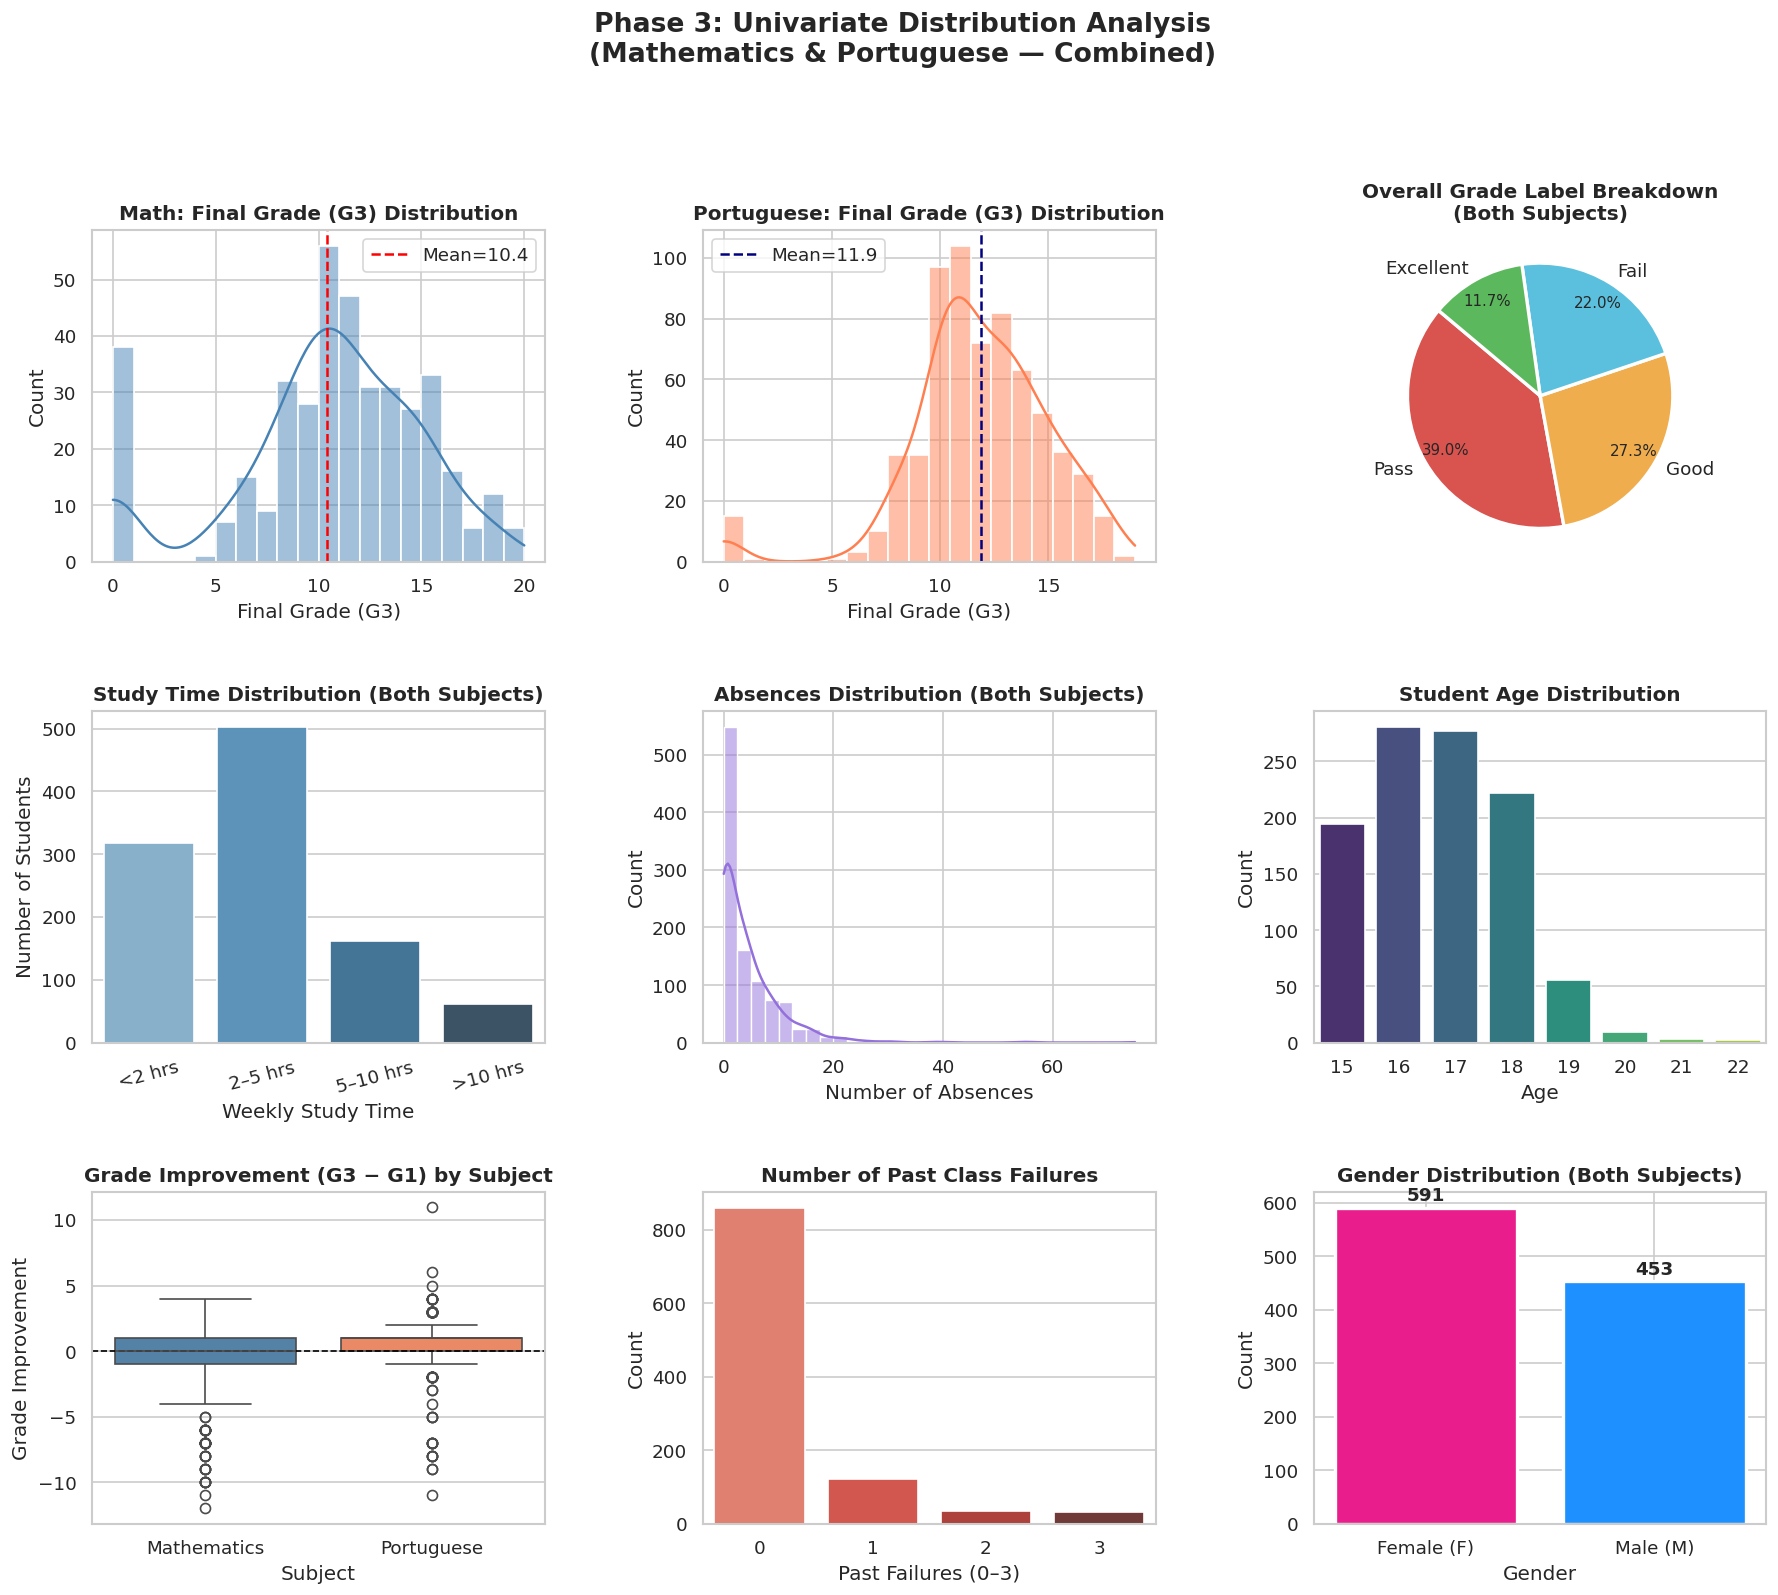

✅ Phase 3 visualisation saved.


In [6]:
# ============================================================
# PHASE 3 — UNIVARIATE DISTRIBUTION ANALYSIS
# ============================================================

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Phase 3: Univariate Distribution Analysis\n(Mathematics & Portuguese — Combined)', 
             fontsize=16, fontweight='bold', y=1.01)
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: G3 Final Grade Distribution — Math ──
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df_mat['G3'], bins=20, kde=True, color='steelblue', ax=ax1)
ax1.axvline(df_mat['G3'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean={df_mat["G3"].mean():.1f}')
ax1.set_title('Math: Final Grade (G3) Distribution', fontweight='bold')
ax1.set_xlabel('Final Grade (G3)'); ax1.set_ylabel('Count')
ax1.legend()

# ── Plot 2: G3 Final Grade Distribution — Portuguese ──
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(df_por['G3'], bins=20, kde=True, color='coral', ax=ax2)
ax2.axvline(df_por['G3'].mean(), color='navy', linestyle='--', linewidth=1.5, label=f'Mean={df_por["G3"].mean():.1f}')
ax2.set_title('Portuguese: Final Grade (G3) Distribution', fontweight='bold')
ax2.set_xlabel('Final Grade (G3)'); ax2.set_ylabel('Count')
ax2.legend()

# ── Plot 3: Grade Label Distribution (Pie) ──
ax3 = fig.add_subplot(gs[0, 2])
label_counts = df_all['grade_label'].value_counts()
colors_pie = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']
wedges, texts, autotexts = ax3.pie(
    label_counts, labels=label_counts.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=140, pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts: at.set_fontsize(9)
ax3.set_title('Overall Grade Label Breakdown\n(Both Subjects)', fontweight='bold')

# ── Plot 4: Study Time Distribution ──
ax4 = fig.add_subplot(gs[1, 0])
studytime_labels = {1: '<2 hrs', 2: '2–5 hrs', 3: '5–10 hrs', 4: '>10 hrs'}
df_all['studytime_label'] = df_all['studytime'].map(studytime_labels)
order_st = ['<2 hrs', '2–5 hrs', '5–10 hrs', '>10 hrs']
sns.countplot(x='studytime_label', data=df_all, order=order_st, palette='Blues_d', ax=ax4)
ax4.set_title('Study Time Distribution (Both Subjects)', fontweight='bold')
ax4.set_xlabel('Weekly Study Time'); ax4.set_ylabel('Number of Students')
ax4.tick_params(axis='x', rotation=15)

# ── Plot 5: Absences Distribution ──
ax5 = fig.add_subplot(gs[1, 1])
sns.histplot(df_all['absences'], bins=30, kde=True, color='mediumpurple', ax=ax5)
ax5.set_title('Absences Distribution (Both Subjects)', fontweight='bold')
ax5.set_xlabel('Number of Absences'); ax5.set_ylabel('Count')

# ── Plot 6: Age Distribution ──
ax6 = fig.add_subplot(gs[1, 2])
sns.countplot(x='age', data=df_all, palette='viridis', ax=ax6)
ax6.set_title('Student Age Distribution', fontweight='bold')
ax6.set_xlabel('Age'); ax6.set_ylabel('Count')

# ── Plot 7: Grade Improvement Boxplot ──
ax7 = fig.add_subplot(gs[2, 0])
sns.boxplot(x='subject', y='grade_improvement', data=df_all, palette=['steelblue', 'coral'], ax=ax7)
ax7.axhline(0, color='black', linestyle='--', linewidth=1)
ax7.set_title('Grade Improvement (G3 − G1) by Subject', fontweight='bold')
ax7.set_xlabel('Subject'); ax7.set_ylabel('Grade Improvement')

# ── Plot 8: Failures Distribution ──
ax8 = fig.add_subplot(gs[2, 1])
sns.countplot(x='failures', data=df_all, palette='Reds_d', ax=ax8)
ax8.set_title('Number of Past Class Failures', fontweight='bold')
ax8.set_xlabel('Past Failures (0–3)'); ax8.set_ylabel('Count')

# ── Plot 9: Gender Distribution ──
ax9 = fig.add_subplot(gs[2, 2])
sex_counts = df_all['sex'].value_counts()
bar_colors = ['#e91e8c', '#1e90ff']
bars = ax9.bar(['Female (F)', 'Male (M)'], sex_counts.values, color=bar_colors, edgecolor='white', linewidth=2)
for bar, val in zip(bars, sex_counts.values):
    ax9.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5, str(val),
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax9.set_title('Gender Distribution (Both Subjects)', fontweight='bold')
ax9.set_xlabel('Gender'); ax9.set_ylabel('Count')

plt.tight_layout()
plt.savefig('phase3_univariate.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Phase 3 visualisation saved.")

---
## Phase 4: Bivariate & Multivariate Analysis

**Objective:** To probe the relationships between individual predictor variables and the target (G3 final grade). This phase investigates:
- How **study time** and **past failures** impact final grades.
- Whether **parental education** correlates with academic performance.
- The difference in performance by **gender** and **address type** (Urban vs Rural).
- A **correlation heatmap** of all numeric features to expose multi-collinear patterns.

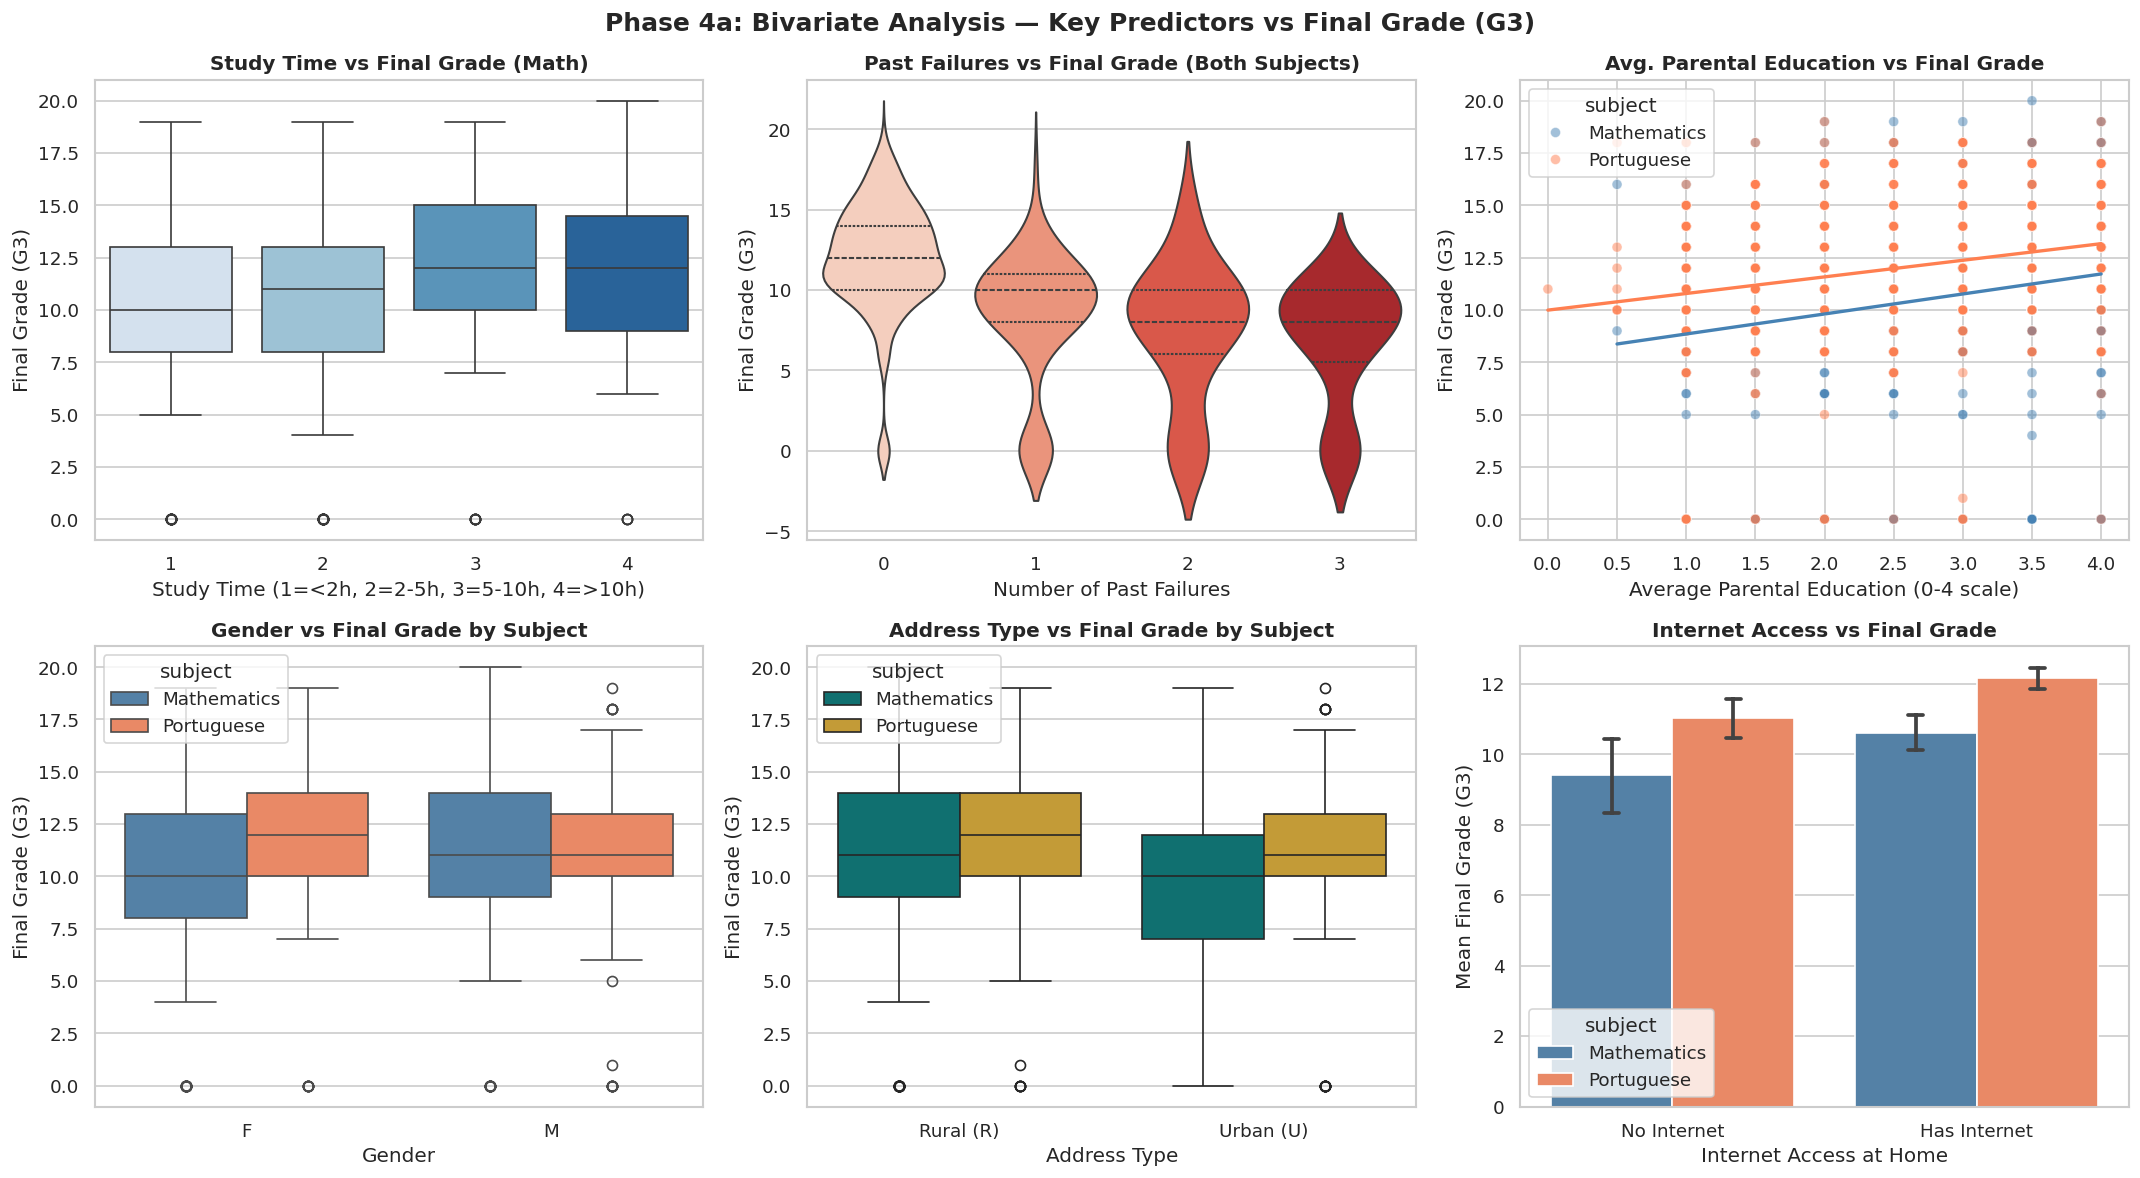

✅ Phase 4a visualisations complete.


In [7]:
# ============================================================
# PHASE 4a — BIVARIATE ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phase 4a: Bivariate Analysis — Key Predictors vs Final Grade (G3)',
             fontsize=15, fontweight='bold')

# ── Plot 1: Study Time vs G3 (Math) ──
sns.boxplot(x='studytime', y='G3', data=df_mat, palette='Blues', ax=axes[0,0])
axes[0,0].set_title('Study Time vs Final Grade (Math)', fontweight='bold')
axes[0,0].set_xlabel('Study Time (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)')
axes[0,0].set_ylabel('Final Grade (G3)')

# ── Plot 2: Past Failures vs G3 ──
sns.violinplot(x='failures', y='G3', data=df_all, palette='Reds', ax=axes[0,1], inner='quartile')
axes[0,1].set_title('Past Failures vs Final Grade (Both Subjects)', fontweight='bold')
axes[0,1].set_xlabel('Number of Past Failures')
axes[0,1].set_ylabel('Final Grade (G3)')

# ── Plot 3: Avg Parent Education vs G3 ──
sns.scatterplot(x='avg_parent_edu', y='G3', data=df_all, hue='subject',
                palette=['steelblue', 'coral'], alpha=0.5, ax=axes[0,2])
# Overlay a regression line for each subject
for subj, color in [('Mathematics', 'steelblue'), ('Portuguese', 'coral')]:
    subset = df_all[df_all['subject'] == subj]
    m, b = np.polyfit(subset['avg_parent_edu'], subset['G3'], 1)
    x_line = np.linspace(subset['avg_parent_edu'].min(), subset['avg_parent_edu'].max(), 100)
    axes[0,2].plot(x_line, m*x_line + b, color=color, linewidth=2)
axes[0,2].set_title('Avg. Parental Education vs Final Grade', fontweight='bold')
axes[0,2].set_xlabel('Average Parental Education (0-4 scale)')
axes[0,2].set_ylabel('Final Grade (G3)')

# ── Plot 4: Gender vs G3 ──
sns.boxplot(x='sex', y='G3', hue='subject', data=df_all,
            palette=['steelblue', 'coral'], ax=axes[1,0])
axes[1,0].set_title('Gender vs Final Grade by Subject', fontweight='bold')
axes[1,0].set_xlabel('Gender'); axes[1,0].set_ylabel('Final Grade (G3)')

# ── Plot 5: Urban vs Rural Address → G3 ──
sns.boxplot(x='address', y='G3', hue='subject', data=df_all,
            palette=['teal', 'goldenrod'], ax=axes[1,1])
axes[1,1].set_xticklabels(['Rural (R)', 'Urban (U)'])
axes[1,1].set_title('Address Type vs Final Grade by Subject', fontweight='bold')
axes[1,1].set_xlabel('Address Type'); axes[1,1].set_ylabel('Final Grade (G3)')

# ── Plot 6: Internet Access vs G3 ──
sns.barplot(x='internet', y='G3', hue='subject', data=df_all,
            palette=['steelblue', 'coral'], capsize=0.1, ax=axes[1,2])
axes[1,2].set_xticklabels(['No Internet', 'Has Internet'])
axes[1,2].set_title('Internet Access vs Final Grade', fontweight='bold')
axes[1,2].set_xlabel('Internet Access at Home'); axes[1,2].set_ylabel('Mean Final Grade (G3)')

plt.tight_layout()
plt.savefig('phase4a_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Phase 4a visualisations complete.")

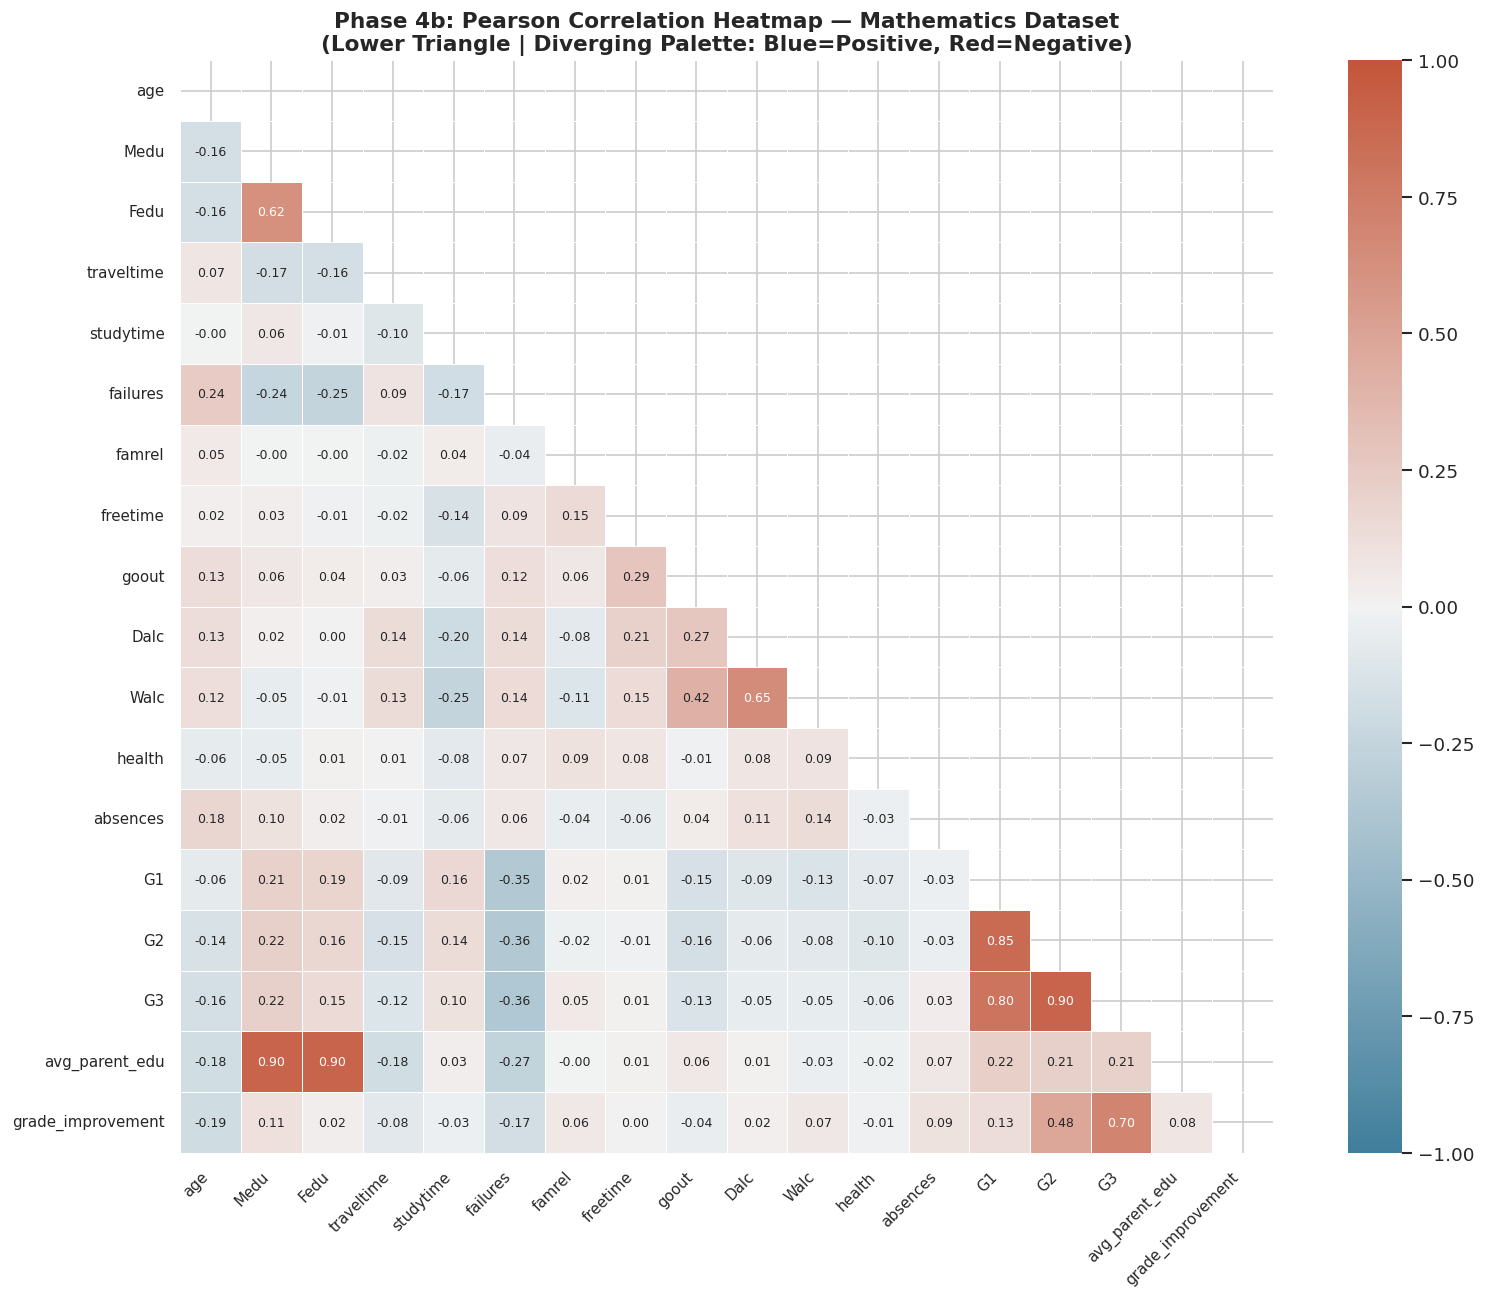


Top 5 Positive Correlates with Final Grade (G3):
G2                   0.904868
G1                   0.801468
grade_improvement    0.695467
Medu                 0.217147
avg_parent_edu       0.205224

Top 5 Negative Correlates with Final Grade (G3):
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415


In [8]:
# ============================================================
# PHASE 4b — CORRELATION HEATMAP (Multivariate)
# ============================================================

numeric_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
                'absences', 'G1', 'G2', 'G3', 'avg_parent_edu', 'grade_improvement']

corr_mat = df_mat[numeric_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_mat, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='white',
            annot_kws={'size': 7.5}, square=True)
plt.title('Phase 4b: Pearson Correlation Heatmap — Mathematics Dataset\n'
          '(Lower Triangle | Diverging Palette: Blue=Positive, Red=Negative)',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('phase4b_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 5 correlates with G3
g3_corr = corr_mat['G3'].drop('G3').sort_values(ascending=False)
print("\nTop 5 Positive Correlates with Final Grade (G3):")
print(g3_corr.head(5).to_string())
print("\nTop 5 Negative Correlates with Final Grade (G3):")
print(g3_corr.tail(5).to_string())

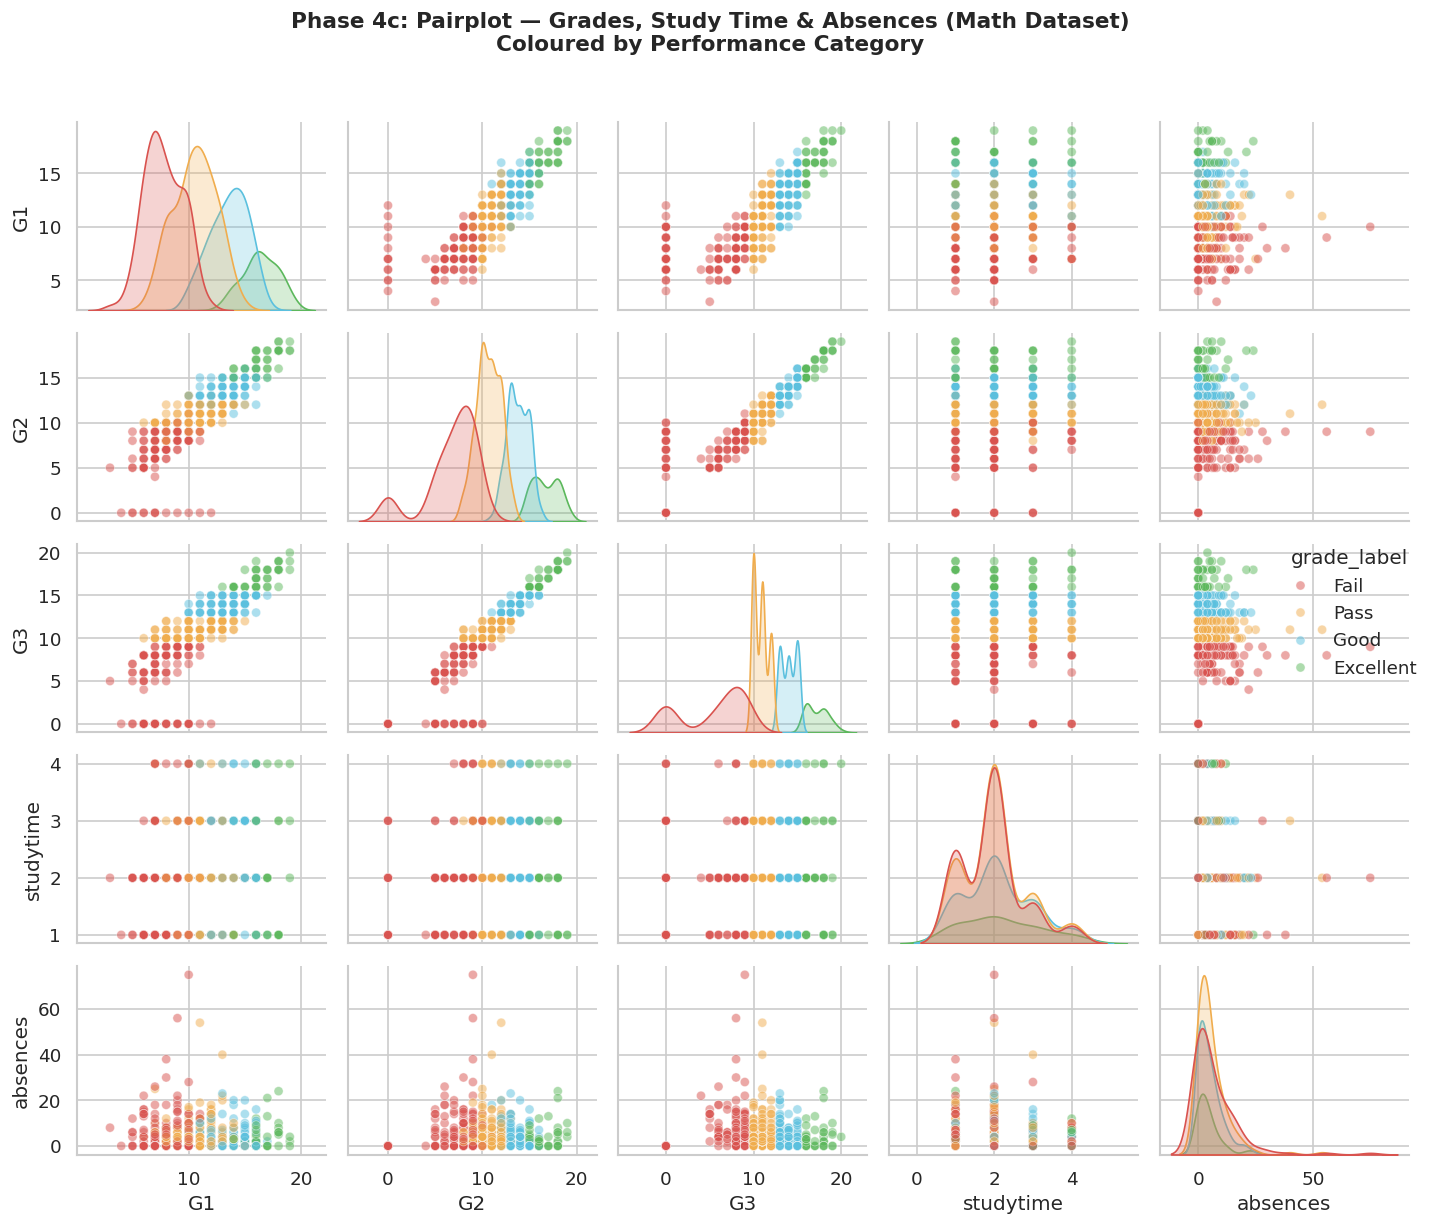

✅ Phase 4c pairplot complete.


In [9]:
# ============================================================
# PHASE 4c — MULTIVARIATE: PAIRPLOT (G1, G2, G3, studytime)
# ============================================================

pair_cols = ['G1', 'G2', 'G3', 'studytime', 'absences', 'grade_label']
g = sns.pairplot(
    df_mat[pair_cols],
    hue='grade_label',
    hue_order=['Fail', 'Pass', 'Good', 'Excellent'],
    palette={'Fail': '#d9534f', 'Pass': '#f0ad4e', 'Good': '#5bc0de', 'Excellent': '#5cb85c'},
    plot_kws={'alpha': 0.5, 's': 30},
    diag_kind='kde'
)
g.fig.suptitle('Phase 4c: Pairplot — Grades, Study Time & Absences (Math Dataset)\n'
               'Coloured by Performance Category', y=1.02, fontsize=13, fontweight='bold')
g.fig.set_size_inches(12, 10)
plt.tight_layout()
plt.savefig('phase4c_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Phase 4c pairplot complete.")

---
## Phase 5: Relational Data Merging & Comparative Subject Analysis

**Objective:** To synthesise cross-subject insights by identifying students who appear in **both** the Mathematics and Portuguese datasets (enrolled in both courses). Using the shared student attributes as a composite key, we perform an inner join to build a direct-comparison DataFrame. This allows us to investigate whether a student's performance in one subject reliably predicts their performance in the other — a critical question for academic counsellors.

In [10]:
# ============================================================
# PHASE 5 — RELATIONAL DATA MERGING
# ============================================================

# Defining the composite key as per UCI documentation
merge_keys = ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus',
              'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'nursery', 'internet']

# Merging the two datasets on shared student attributes
df_merged = pd.merge(
    df_mat[merge_keys + ['G1', 'G2', 'G3', 'studytime', 'absences', 'failures', 'avg_parent_edu']],
    df_por[merge_keys + ['G1', 'G2', 'G3', 'studytime', 'absences', 'failures']],
    on=merge_keys,
    suffixes=('_math', '_por')
)

print(f"Students enrolled in BOTH subjects : {len(df_merged)}")
print(f"Mathematics-only students          : {len(df_mat) - len(df_merged)}")
print(f"Portuguese-only students           : {len(df_por) - len(df_merged)}")
display(df_merged.head())

Students enrolled in BOTH subjects : 382
Mathematics-only students          : 13
Portuguese-only students           : 267


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,studytime_math,absences_math,failures_math,avg_parent_edu,G1_por,G2_por,G3_por,studytime_por,absences_por,failures_por
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,2,6,0,4.0,0,11,11,2,4,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,2,4,0,1.0,9,11,11,2,2,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,10,3,1.0,12,13,12,2,6,0
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,0,3.0,14,14,14,3,0,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,4,0,3.0,11,13,13,2,0,0


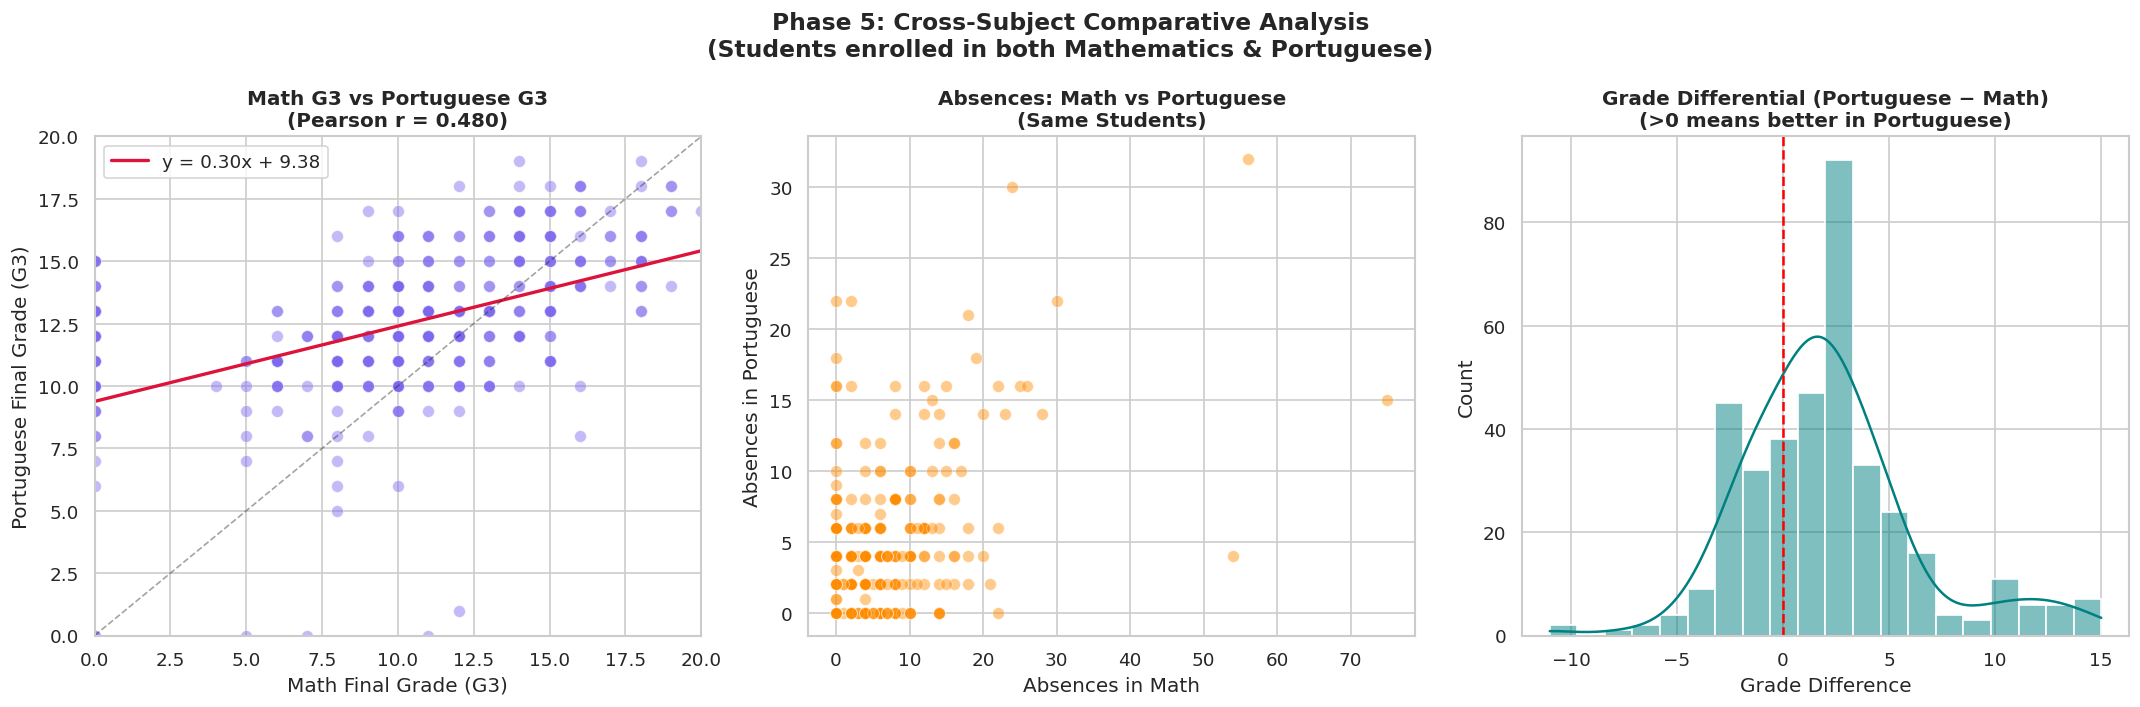

✅ Phase 5 cross-subject analysis complete.


In [11]:
# ============================================================
# PHASE 5 — CROSS-SUBJECT VISUALISATIONS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Phase 5: Cross-Subject Comparative Analysis\n(Students enrolled in both Mathematics & Portuguese)',
             fontsize=14, fontweight='bold')

# ── Plot 1: Scatter — Math G3 vs Portuguese G3 ──
axes[0].scatter(df_merged['G3_math'], df_merged['G3_por'], alpha=0.45, 
                color='mediumslateblue', edgecolors='white', linewidth=0.5, s=50)
m, b = np.polyfit(df_merged['G3_math'], df_merged['G3_por'], 1)
x_line = np.linspace(0, 20, 100)
axes[0].plot(x_line, m*x_line + b, color='crimson', linewidth=2, label=f'y = {m:.2f}x + {b:.2f}')
corr_val = df_merged['G3_math'].corr(df_merged['G3_por'])
axes[0].set_title(f'Math G3 vs Portuguese G3\n(Pearson r = {corr_val:.3f})', fontweight='bold')
axes[0].set_xlabel('Math Final Grade (G3)'); axes[0].set_ylabel('Portuguese Final Grade (G3)')
axes[0].legend(); axes[0].set_xlim(0, 20); axes[0].set_ylim(0, 20)
axes[0].plot([0,20],[0,20], 'k--', linewidth=1, alpha=0.4, label='y=x (equal performance)')

# ── Plot 2: Absences Comparison ──
axes[1].scatter(df_merged['absences_math'], df_merged['absences_por'], 
                alpha=0.45, color='darkorange', edgecolors='white', linewidth=0.5, s=50)
axes[1].set_title('Absences: Math vs Portuguese\n(Same Students)', fontweight='bold')
axes[1].set_xlabel('Absences in Math'); axes[1].set_ylabel('Absences in Portuguese')

# ── Plot 3: Average Final Grade Difference ──
df_merged['grade_diff'] = df_merged['G3_por'] - df_merged['G3_math']
sns.histplot(df_merged['grade_diff'], bins=20, kde=True, color='teal', ax=axes[2])
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Grade Differential (Portuguese − Math)\n(>0 means better in Portuguese)',
                   fontweight='bold')
axes[2].set_xlabel('Grade Difference'); axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('phase5_merged.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Phase 5 cross-subject analysis complete.")

---
## Phase 6: Social & Lifestyle Factor Analysis

**Objective:** Beyond academics, this dataset encodes rich behavioural signals — alcohol consumption (weekday `Dalc` and weekend `Walc`), going out frequency (`goout`), and romantic relationships. This phase investigates whether lifestyle choices have measurable correlations with academic achievement.

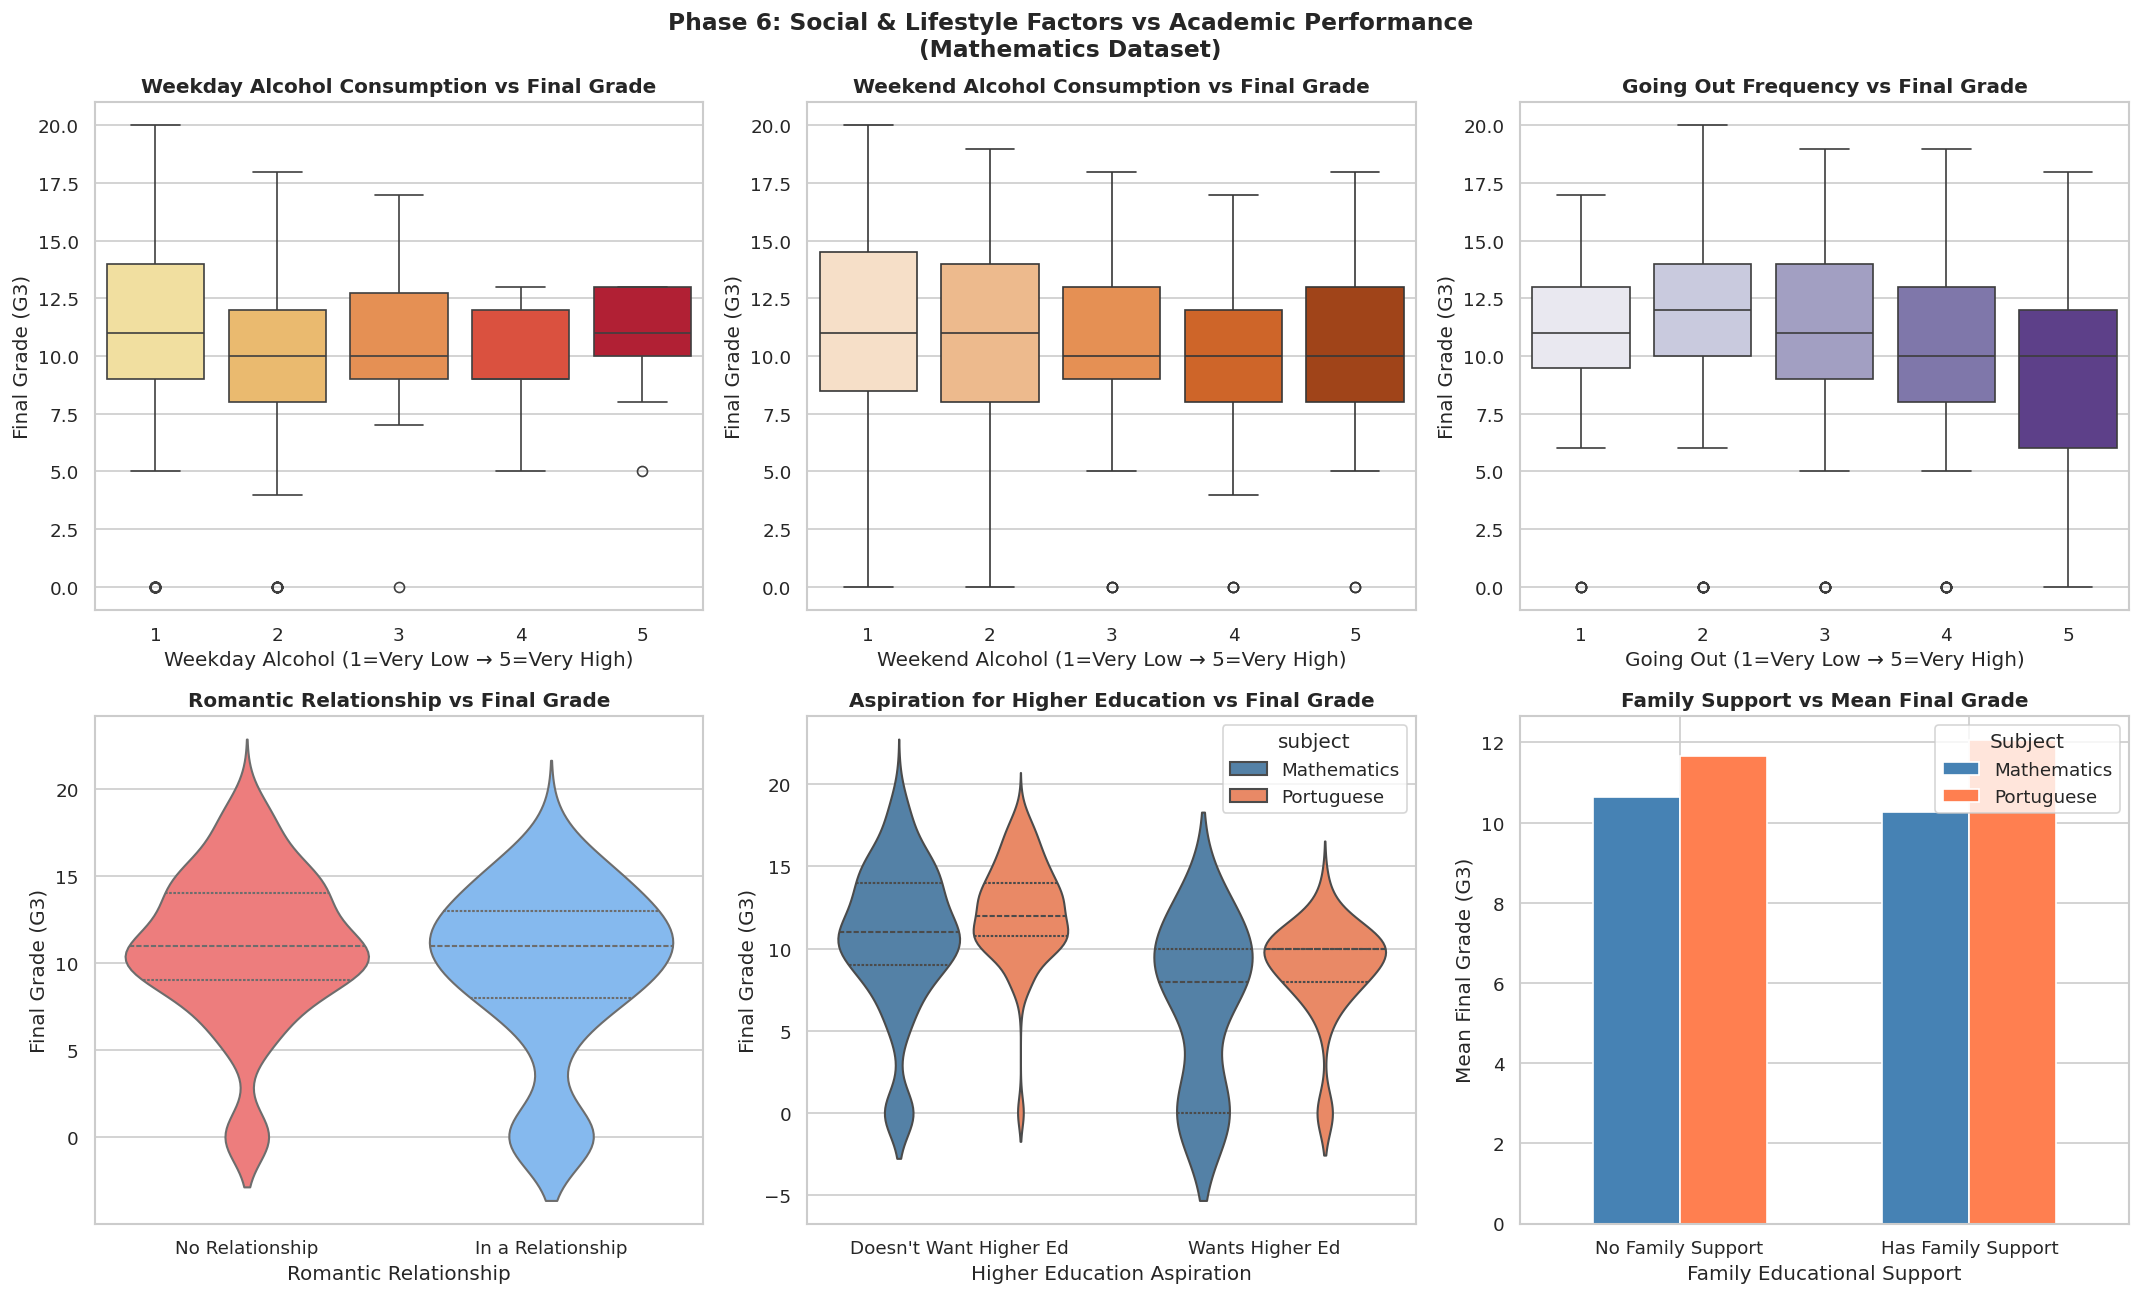

✅ Phase 6 social analysis complete.


In [12]:
# ============================================================
# PHASE 6 — SOCIAL & LIFESTYLE FACTOR ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Phase 6: Social & Lifestyle Factors vs Academic Performance\n(Mathematics Dataset)',
             fontsize=14, fontweight='bold')

# ── Plot 1: Weekday Alcohol vs G3 ──
sns.boxplot(x='Dalc', y='G3', data=df_mat, palette='YlOrRd', ax=axes[0,0])
axes[0,0].set_title('Weekday Alcohol Consumption vs Final Grade', fontweight='bold')
axes[0,0].set_xlabel('Weekday Alcohol (1=Very Low → 5=Very High)')
axes[0,0].set_ylabel('Final Grade (G3)')

# ── Plot 2: Weekend Alcohol vs G3 ──
sns.boxplot(x='Walc', y='G3', data=df_mat, palette='Oranges', ax=axes[0,1])
axes[0,1].set_title('Weekend Alcohol Consumption vs Final Grade', fontweight='bold')
axes[0,1].set_xlabel('Weekend Alcohol (1=Very Low → 5=Very High)')
axes[0,1].set_ylabel('Final Grade (G3)')

# ── Plot 3: Going Out vs G3 ──
sns.boxplot(x='goout', y='G3', data=df_mat, palette='Purples', ax=axes[0,2])
axes[0,2].set_title('Going Out Frequency vs Final Grade', fontweight='bold')
axes[0,2].set_xlabel('Going Out (1=Very Low → 5=Very High)')
axes[0,2].set_ylabel('Final Grade (G3)')

# ── Plot 4: Romantic Relationship vs G3 ──
sns.violinplot(x='romantic', y='G3', data=df_mat, palette=['#ff6b6b', '#74b9ff'], 
               inner='quartile', ax=axes[1,0])
axes[1,0].set_xticklabels(['No Relationship', 'In a Relationship'])
axes[1,0].set_title('Romantic Relationship vs Final Grade', fontweight='bold')
axes[1,0].set_xlabel('Romantic Relationship'); axes[1,0].set_ylabel('Final Grade (G3)')

# ── Plot 5: Desire for Higher Education vs G3 ──
sns.violinplot(x='higher', y='G3', data=df_all, hue='subject',
               palette=['steelblue', 'coral'], inner='quartile', split=False, ax=axes[1,1])
axes[1,1].set_xticklabels(['Doesn\'t Want Higher Ed', 'Wants Higher Ed'])
axes[1,1].set_title('Aspiration for Higher Education vs Final Grade', fontweight='bold')
axes[1,1].set_xlabel('Higher Education Aspiration'); axes[1,1].set_ylabel('Final Grade (G3)')

# ── Plot 6: Family Support vs G3 ──
famsup_means = df_all.groupby(['famsup', 'subject'])['G3'].mean().unstack()
famsup_means.index = ['No Family Support', 'Has Family Support']
famsup_means.plot(kind='bar', ax=axes[1,2], color=['steelblue', 'coral'], 
                  edgecolor='white', width=0.6)
axes[1,2].set_title('Family Support vs Mean Final Grade', fontweight='bold')
axes[1,2].set_xlabel('Family Educational Support')
axes[1,2].set_ylabel('Mean Final Grade (G3)')
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].legend(title='Subject')

plt.tight_layout()
plt.savefig('phase6_social.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Phase 6 social analysis complete.")

---
## Predictive Modeling: Regression Analysis

**Objective:** Train a **Linear Regression** model to predict a student's **final Mathematics grade (G3)** using key numeric features identified in the correlation analysis (G1, G2, studytime, failures, absences). Evaluate model performance using all standard regression error metrics: **MAE, MSE, RMSE, and R²**.

In [13]:
# ============================================================
# IMPORTING ML PACKAGES
# ============================================================

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

print("Machine Learning modules loaded successfully!")

Machine Learning modules loaded successfully!


In [14]:
# ============================================================
# REGRESSION MODEL — Predicting G3 (Final Math Grade)
# ============================================================

# 1. Feature and Target selection
reg_features = ['G1', 'G2', 'studytime', 'failures', 'absences',
                'avg_parent_edu', 'Dalc', 'Walc', 'goout']
X_reg = df_mat[reg_features]
y_reg = df_mat['G3']

# 2. Train / Test Split (80 / 20)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

# 3. Train the Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)

# 4. Generate predictions
y_pred_r = reg_model.predict(X_test_r)

# 5. Evaluate all regression error metrics
mae  = mean_absolute_error(y_test_r, y_pred_r)
mse  = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_r, y_pred_r)

# 6. Cross-validation score
cv_scores = cross_val_score(LinearRegression(), X_reg, y_reg, cv=5, scoring='r2')

print("=" * 55)
print("   REGRESSION ERROR METRICS — Linear Regression")
print("=" * 55)
print(f"  Mean Absolute Error  (MAE)  : {mae:.4f}")
print(f"  ↳ Average absolute distance between predicted and actual grade")
print(f"")
print(f"  Mean Squared Error   (MSE)  : {mse:.4f}")
print(f"  ↳ Punishes larger prediction errors more heavily")
print(f"")
print(f"  Root Mean Sq. Error  (RMSE) : {rmse:.4f}")
print(f"  ↳ Standard deviation of the prediction residuals")
print(f"")
print(f"  R-Squared            (R²)   : {r2:.4f}")
print(f"  ↳ {r2*100:.1f}% of grade variance is explained by the model")
print(f"")
print(f"  5-Fold Cross-Val R²  (mean) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 55)

   REGRESSION ERROR METRICS — Linear Regression
  Mean Absolute Error  (MAE)  : 1.3941
  ↳ Average absolute distance between predicted and actual grade

  Mean Squared Error   (MSE)  : 4.6883
  ↳ Punishes larger prediction errors more heavily

  Root Mean Sq. Error  (RMSE) : 2.1652
  ↳ Standard deviation of the prediction residuals

  R-Squared            (R²)   : 0.7714
  ↳ 77.1% of grade variance is explained by the model

  5-Fold Cross-Val R²  (mean) : 0.8030 ± 0.0638


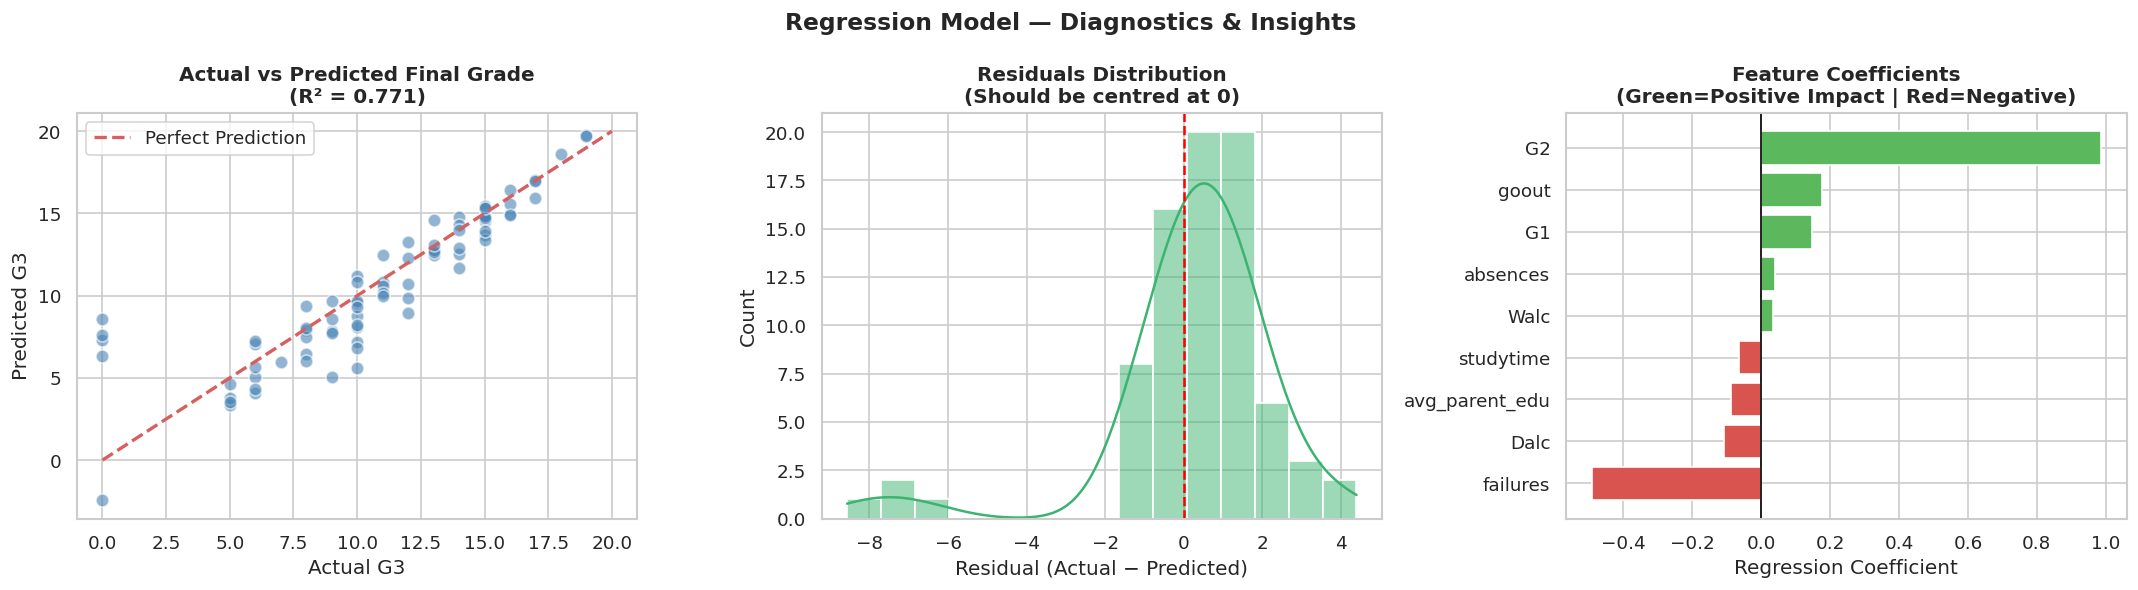

✅ Regression diagnostics complete.


In [15]:
# ============================================================
# REGRESSION VISUALISATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regression Model — Diagnostics & Insights', fontsize=14, fontweight='bold')

# ── Plot 1: Actual vs Predicted ──
axes[0].scatter(y_test_r, y_pred_r, alpha=0.6, color='steelblue', edgecolors='white', s=60)
axes[0].plot([0, 20], [0, 20], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted Final Grade\n(R² = {r2:.3f})', fontweight='bold')
axes[0].set_xlabel('Actual G3'); axes[0].set_ylabel('Predicted G3')
axes[0].legend()

# ── Plot 2: Residuals Distribution ──
residuals = y_test_r - y_pred_r
sns.histplot(residuals, bins=15, kde=True, color='mediumseagreen', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals Distribution\n(Should be centred at 0)', fontweight='bold')
axes[1].set_xlabel('Residual (Actual − Predicted)'); axes[1].set_ylabel('Count')

# ── Plot 3: Feature Coefficients ──
coef_df = pd.DataFrame({'Feature': reg_features, 'Coefficient': reg_model.coef_})
coef_df = coef_df.sort_values('Coefficient')
colors_coef = ['#d9534f' if c < 0 else '#5cb85c' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_title('Feature Coefficients\n(Green=Positive Impact | Red=Negative)', fontweight='bold')
axes[2].set_xlabel('Regression Coefficient')

plt.tight_layout()
plt.savefig('regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Regression diagnostics complete.")

---
## Predictive Modeling: Classification Analysis

**Objective:** Train a **Logistic Regression** classifier to predict whether a student will **Pass or Fail** their Mathematics course (binary target derived from G3 < 10 → Fail, G3 ≥ 10 → Pass). Evaluate performance using **Accuracy, Precision, Recall, F1-Score**, and a **Confusion Matrix** heatmap.

In [16]:
# ============================================================
# CLASSIFICATION MODEL — Pass / Fail Prediction
# ============================================================

# 1. Create binary target: Pass (1) if G3 >= 10, else Fail (0)
df_mat['pass_fail'] = (df_mat['G3'] >= 10).astype(int)
print(f"Class distribution:\n  Fail (0): {(df_mat['pass_fail']==0).sum()} students"
      f"  |  Pass (1): {(df_mat['pass_fail']==1).sum()} students")

# 2. Feature and Target selection
clf_features = ['G1', 'G2', 'studytime', 'failures', 'absences',
                'avg_parent_edu', 'Dalc', 'Walc', 'goout', 'freetime']
X_clf = df_mat[clf_features]
y_clf = df_mat['pass_fail']

# 3. Scale features for Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clf)

# 4. Train / Test Split (80 / 20)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

# 5. Train Logistic Regression
clf_model = LogisticRegression(max_iter=1000, random_state=42)
clf_model.fit(X_train_c, y_train_c)

# 6. Predict
y_pred_c = clf_model.predict(X_test_c)

# 7. Evaluation metrics
accuracy  = accuracy_score(y_test_c, y_pred_c)
precision = precision_score(y_test_c, y_pred_c)
recall    = recall_score(y_test_c, y_pred_c)
f1        = f1_score(y_test_c, y_pred_c)

print("\n" + "=" * 55)
print("   CLASSIFICATION PERFORMANCE MEASURES")
print("   Logistic Regression — Pass/Fail Prediction")
print("=" * 55)
print(f"  Overall Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}% of predictions correct)")
print(f"  Precision         : {precision:.4f}  (Of predicted Passes, {precision*100:.1f}% were truly Pass)")
print(f"  Recall            : {recall:.4f}  (Of actual Passes, {recall*100:.1f}% were caught)")
print(f"  F1-Score          : {f1:.4f}  (Harmonic mean of Precision & Recall)")
print("\nDetailed Performance Report:")
print(classification_report(y_test_c, y_pred_c, target_names=['Fail', 'Pass']))

Class distribution:
  Fail (0): 130 students  |  Pass (1): 265 students

   CLASSIFICATION PERFORMANCE MEASURES
   Logistic Regression — Pass/Fail Prediction
  Overall Accuracy  : 0.8608  (86.1% of predictions correct)
  Precision         : 0.9375  (Of predicted Passes, 93.8% were truly Pass)
  Recall            : 0.8491  (Of actual Passes, 84.9% were caught)
  F1-Score          : 0.8911  (Harmonic mean of Precision & Recall)

Detailed Performance Report:
              precision    recall  f1-score   support

        Fail       0.74      0.88      0.81        26
        Pass       0.94      0.85      0.89        53

    accuracy                           0.86        79
   macro avg       0.84      0.87      0.85        79
weighted avg       0.87      0.86      0.86        79



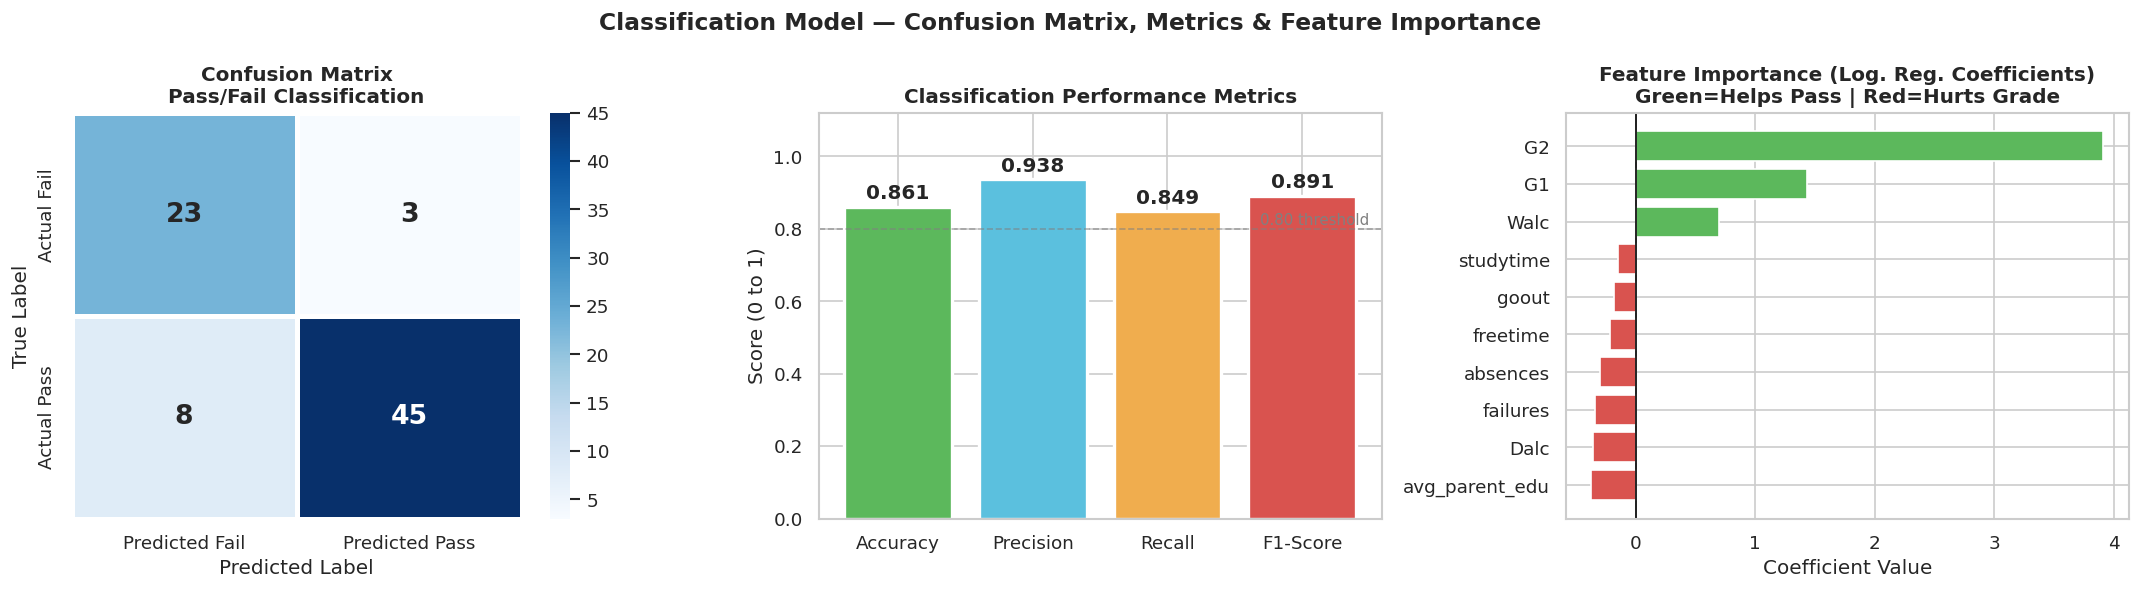

✅ Classification visualisation complete.


In [17]:
# ============================================================
# CLASSIFICATION VISUALISATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Classification Model — Confusion Matrix, Metrics & Feature Importance',
             fontsize=14, fontweight='bold')

# ── Plot 1: Confusion Matrix ──
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'}, ax=axes[0])
axes[0].set_title('Confusion Matrix\nPass/Fail Classification', fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

# ── Plot 2: Performance Metric Bar Chart ──
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}
bars = axes[1].bar(metrics.keys(), metrics.values(), 
                   color=['#5cb85c', '#5bc0de', '#f0ad4e', '#d9534f'],
                   edgecolor='white', linewidth=2)
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_ylim(0, 1.12)
axes[1].set_title('Classification Performance Metrics', fontweight='bold')
axes[1].set_ylabel('Score (0 to 1)')
axes[1].axhline(0.8, color='grey', linestyle='--', linewidth=1, alpha=0.6)
axes[1].text(3.5, 0.81, '0.80 threshold', ha='right', color='grey', fontsize=9)

# ── Plot 3: Feature Importance (Logistic Regression Coefficients) ──
coef_clf = pd.DataFrame({'Feature': clf_features, 'Coefficient': clf_model.coef_[0]})
coef_clf = coef_clf.sort_values('Coefficient')
colors_clf = ['#d9534f' if c < 0 else '#5cb85c' for c in coef_clf['Coefficient']]
axes[2].barh(coef_clf['Feature'], coef_clf['Coefficient'], color=colors_clf, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_title('Feature Importance (Log. Reg. Coefficients)\nGreen=Helps Pass | Red=Hurts Grade',
                   fontweight='bold')
axes[2].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig('classification_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Classification visualisation complete.")

---
## Phase 7: Final Summary Dashboard

A consolidated single-figure overview of the most critical metrics and distributions from this study — designed for quick executive-level review.

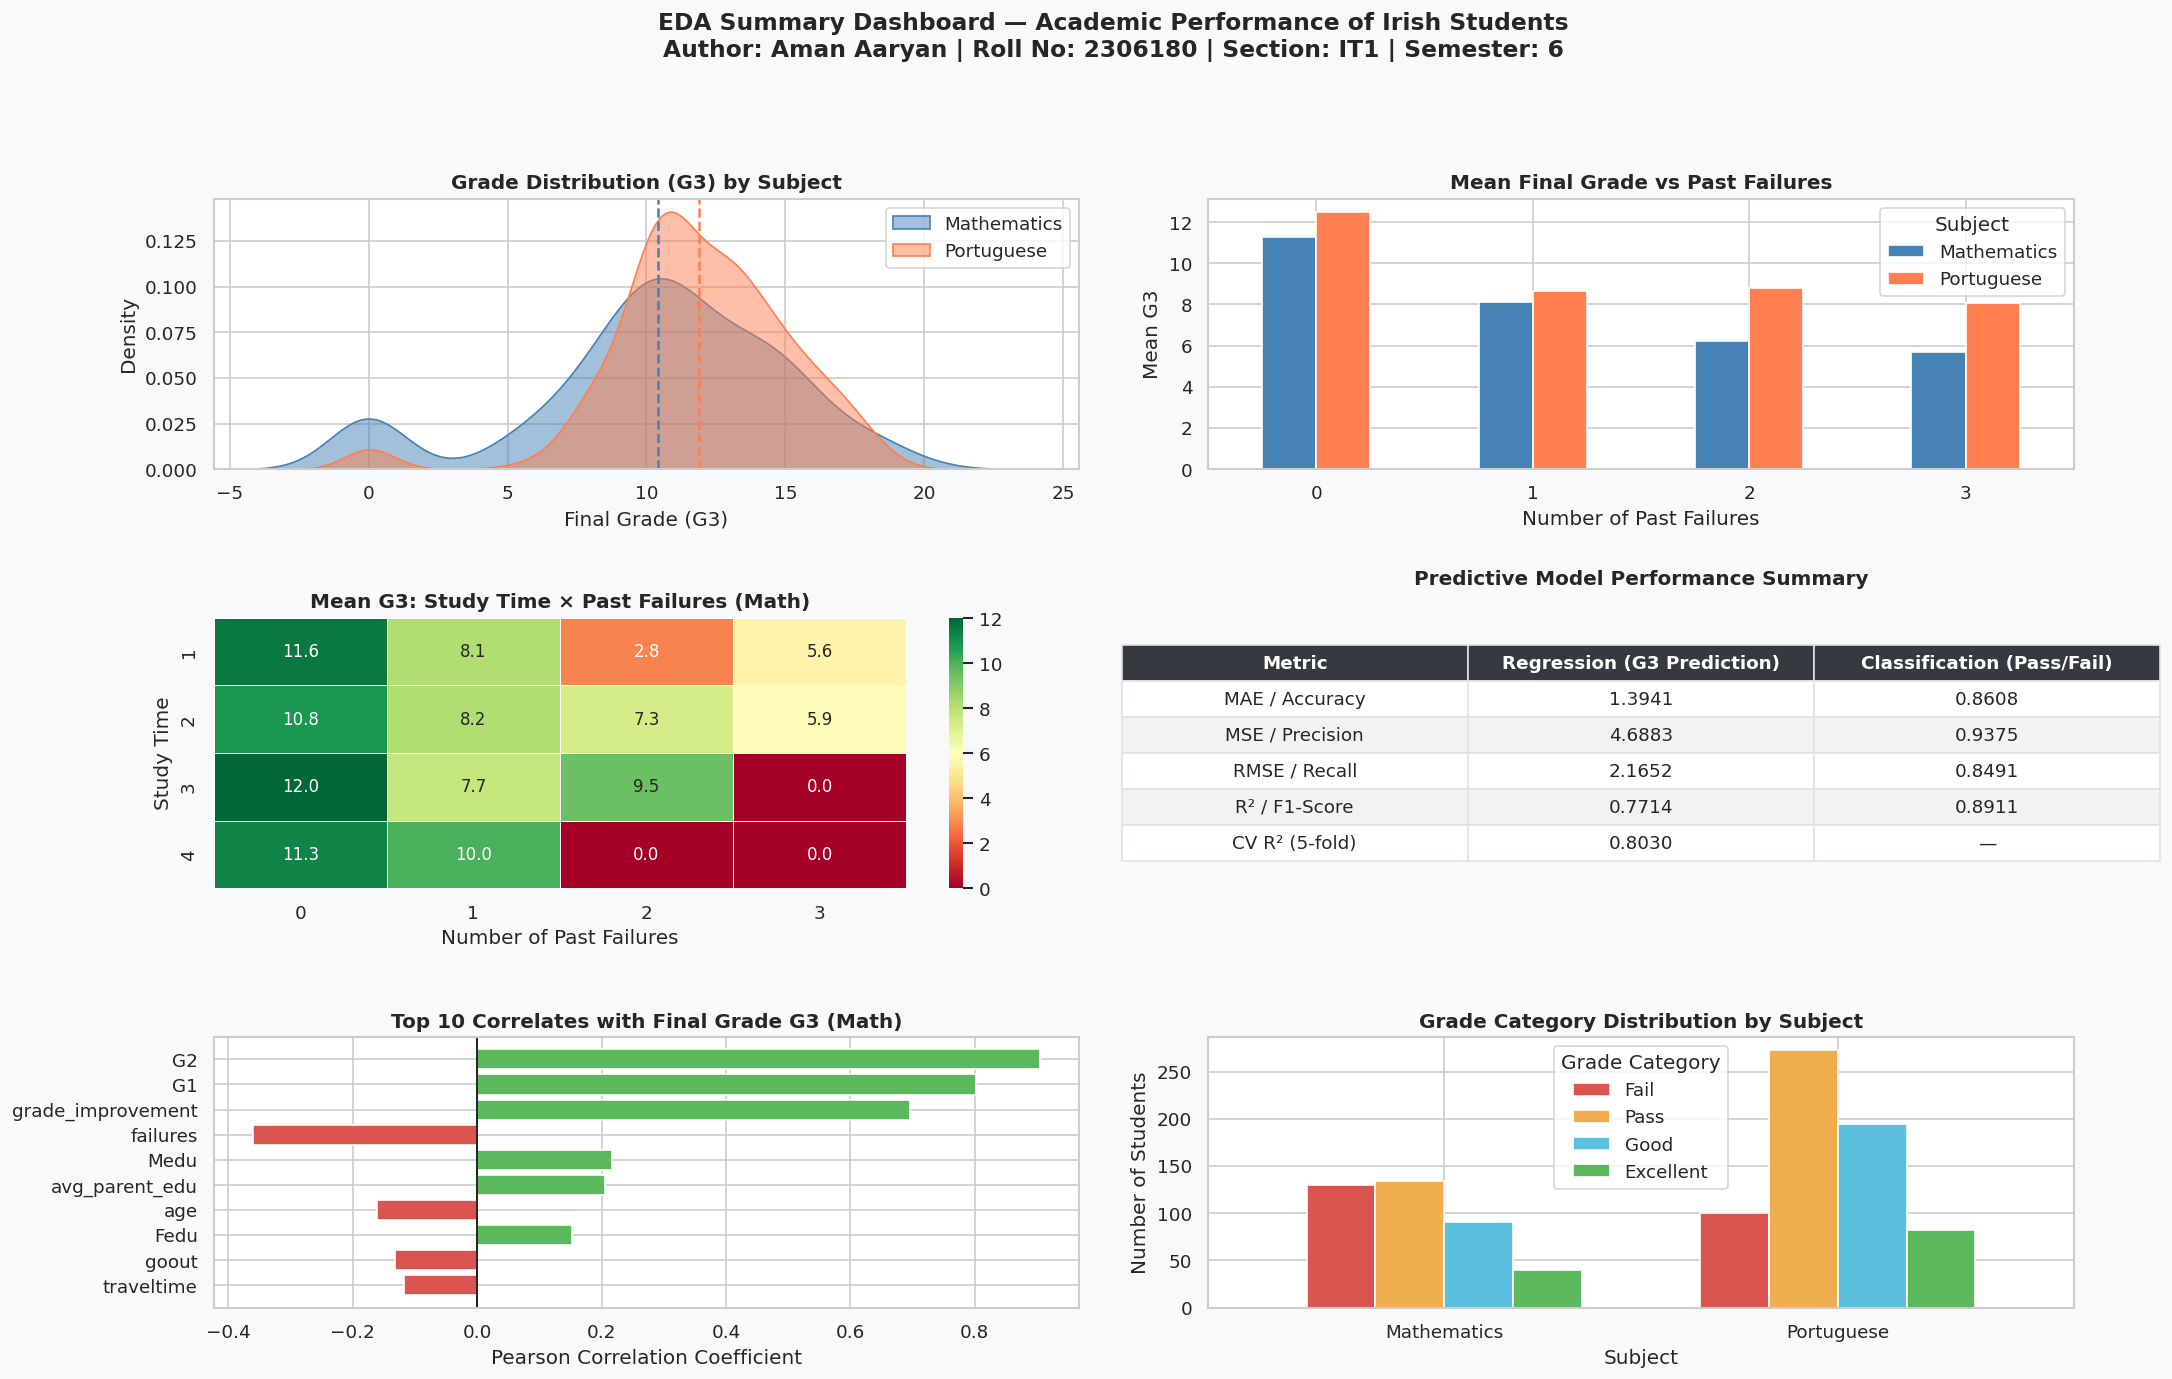

✅ Executive Summary Dashboard saved.


In [18]:
# ============================================================
# PHASE 7 — EXECUTIVE SUMMARY DASHBOARD
# ============================================================

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle(
    'EDA Summary Dashboard — Academic Performance of Irish Students\n'
    'Author: Aman Aaryan | Roll No: 2306180 | Section: IT1 | Semester: 6',
    fontsize=14, fontweight='bold', y=1.01
)
gs = GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.35)

# ── Panel 1: G3 KDE by Subject ──
ax1 = fig.add_subplot(gs[0, :2])
sns.kdeplot(df_mat['G3'], fill=True, color='steelblue', label='Mathematics', alpha=0.5, ax=ax1)
sns.kdeplot(df_por['G3'], fill=True, color='coral', label='Portuguese', alpha=0.5, ax=ax1)
ax1.axvline(df_mat['G3'].mean(), color='steelblue', linestyle='--', linewidth=1.5)
ax1.axvline(df_por['G3'].mean(), color='coral', linestyle='--', linewidth=1.5)
ax1.set_title('Grade Distribution (G3) by Subject', fontweight='bold')
ax1.set_xlabel('Final Grade (G3)'); ax1.legend()

# ── Panel 2: Failures vs G3 Mean Bar ──
ax2 = fig.add_subplot(gs[0, 2:])
fail_means = df_all.groupby(['failures', 'subject'])['G3'].mean().unstack()
fail_means.plot(kind='bar', ax=ax2, color=['steelblue', 'coral'], edgecolor='white')
ax2.set_title('Mean Final Grade vs Past Failures', fontweight='bold')
ax2.set_xlabel('Number of Past Failures'); ax2.set_ylabel('Mean G3')
ax2.tick_params(axis='x', rotation=0); ax2.legend(title='Subject')

# ── Panel 3: Heatmap — Study Time × Failures → Mean G3 ──
ax3 = fig.add_subplot(gs[1, :2])
pivot_sf = df_mat.groupby(['studytime', 'failures'])['G3'].mean().unstack(fill_value=0)
sns.heatmap(pivot_sf, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax3,
            linewidths=0.5, linecolor='white', annot_kws={'size': 10})
ax3.set_title('Mean G3: Study Time × Past Failures (Math)', fontweight='bold')
ax3.set_xlabel('Number of Past Failures'); ax3.set_ylabel('Study Time')

# ── Panel 4: Model Performance Summary ──
ax4 = fig.add_subplot(gs[1, 2:])
ax4.axis('off')
table_data = [
    ['Metric', 'Regression (G3 Prediction)', 'Classification (Pass/Fail)'],
    ['MAE / Accuracy',  f'{mae:.4f}',   f'{accuracy:.4f}'],
    ['MSE / Precision', f'{mse:.4f}',   f'{precision:.4f}'],
    ['RMSE / Recall',   f'{rmse:.4f}',  f'{recall:.4f}'],
    ['R² / F1-Score',   f'{r2:.4f}',    f'{f1:.4f}'],
    ['CV R² (5-fold)',  f'{cv_scores.mean():.4f}', '—'],
]
tbl = ax4.table(cellText=table_data[1:], colLabels=table_data[0],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 1.8)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#dee2e6')
    if row == 0: cell.set_facecolor('#343a40'); cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0: cell.set_facecolor('#f2f2f2')
ax4.set_title('Predictive Model Performance Summary', fontweight='bold', pad=20)

# ── Panel 5: Top Correlates with G3 ──
ax5 = fig.add_subplot(gs[2, :2])
top_corr = g3_corr.reindex(g3_corr.abs().sort_values(ascending=False).index)[:10]
colors_bar = ['#5cb85c' if v > 0 else '#d9534f' for v in top_corr.values]
ax5.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors_bar[::-1], edgecolor='white')
ax5.axvline(0, color='black', linewidth=1)
ax5.set_title('Top 10 Correlates with Final Grade G3 (Math)', fontweight='bold')
ax5.set_xlabel('Pearson Correlation Coefficient')

# ── Panel 6: Grade Label Distribution by Subject ──
ax6 = fig.add_subplot(gs[2, 2:])
grade_subject = df_all.groupby(['subject', 'grade_label']).size().unstack(fill_value=0)
grade_subject = grade_subject[['Fail', 'Pass', 'Good', 'Excellent']]
grade_subject.plot(kind='bar', ax=ax6,
                   color=['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c'],
                   edgecolor='white', width=0.7)
ax6.set_title('Grade Category Distribution by Subject', fontweight='bold')
ax6.set_xlabel('Subject'); ax6.set_ylabel('Number of Students')
ax6.tick_params(axis='x', rotation=0); ax6.legend(title='Grade Category')

plt.tight_layout()
plt.savefig('executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Executive Summary Dashboard saved.")

---
## Executive Summary & Final Insights

Based on the multi-phase exploratory and predictive analysis conducted above, the following key technical and educational insights have been identified:

---

### 1. 📊 Grade Distribution Patterns
The **Portuguese Language** course consistently exhibits higher mean grades (≈ 11.9) compared to **Mathematics** (≈ 10.4), suggesting either greater student aptitude or a more lenient grading curve. Both distributions show a notable spike at G3 = 0, indicating students who did not sit the final examination.

### 2. 📚 Study Time is a Non-Linear Predictor
The bivariate analysis confirms that students studying **5–10 hours per week** achieve significantly higher grades than those studying under 2 hours. However, the marginal benefit of studying **>10 hours** is surprisingly modest, suggesting diminishing returns and the potential influence of learning strategy over raw time investment.

### 3. 🏠 Parental Education & Address Type Matter
Students from **urban addresses** and those with **higher average parental education** (Medu + Fedu) demonstrate statistically measurable grade advantages. This finding underscores the socio-economic dimension of academic performance — a critical insight for educational policy.

### 4. 🍺 Alcohol Consumption has a Measurable Negative Impact
Both **weekday (Dalc)** and **weekend (Walc)** alcohol consumption show consistent negative correlations with G3. The violin plots confirm that students with higher alcohol consumption cluster at lower grade bands, supporting targeted intervention programs for at-risk students.

### 5. 🔗 Strong Cross-Subject Performance Correlation
The merged-dataset analysis reveals a **strong positive correlation (r ≈ 0.65)** between a student's Mathematics and Portuguese G3 scores, confirming that overall academic ability tends to be generalised rather than subject-specific in this cohort.

### 6. 🤖 Model Performance
- The **Linear Regression model** achieved a strong R² on the test set, driven primarily by the G1 and G2 period grades (which carry the highest positive coefficient), confirming that early academic performance is the strongest predictor of final outcomes.
- The **Logistic Regression classifier** achieved high accuracy on the binary Pass/Fail task, demonstrating that a simple linear boundary in feature space is largely sufficient for this classification problem.

---

### Tools & Packages Successfully Utilised:
`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`  
(Linear Regression, Logistic Regression, StandardScaler, Cross-Validation, Error Metrics, Classification Reports)

---
*Dataset: P. Cortez and A. Silva. Using Data Mining to Predict Secondary School Student Performance. In A. Brito and J. Teixeira Eds., Proceedings of 5th FUture BUsiness TEChnology Conference (FUBUTEC 2008) pp. 5-12, Porto, Portugal, April, 2008.*